<a href="https://colab.research.google.com/github/vishal786-commits/machine-learning-journey/blob/main/classical-ml/decision-trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Author: Vishal Gopalkrishna**

# **Decision Trees from Scratch** 🌳

In this notebook we will build a **Decision Tree classifier from first principles**.

**Goals:**
- Understand the intuition behind decision trees
- Learn concepts like **entropy, information gain, and splitting**
- Implement a **decision tree algorithm from scratch using Python**
- Avoid using high-level ML libraries

Why this matters:
Decision Trees are the foundation of powerful models like **Random Forests and Gradient Boosting (XGBoost, LightGBM)**.

---

## **The Core Intuition**

Imagine you are trying to guess **whether someone will buy a product**.

You can ask questions to help you decide.

**For example:**

* "Are they younger than 30?"
* "Do they earn a lot of money?"

Each question helps you **split people into smaller groups**.

A **Decision Tree** works the same way. It keeps asking questions until the answer becomes very clear.

Think of it like a **20 Questions game**.

---

### **Step 1: Start With Everyone**

Suppose we have this information about some people:

| Income | Age | Buy Product |
| ------ | --- | ----------- |
| Low    | 22  | No          |
| High   | 45  | Yes         |
| Medium | 30  | Yes         |

Right now everything is **mixed together**.

Some people buy the product, some don’t.

So the computer needs to **ask a smart question**.

---

### **Step 2: Ask a Question**

The computer might ask:

**“Is Age less than 30?”**

Now the data splits into two groups.

**Group 1 (Age < 30)**

* 22 → No

**Group 2 (Age ≥ 30)**

* 45 → Yes
* 30 → Yes

---

### **Step 3: Look at the Groups**

Now check what happened.

**Group 1:**
Only one person → they did **NOT buy**.

**Group 2:**
Both people → **bought the product**.

Now each group is **very clear**.

One group = all **No**
Other group = all **Yes**

This is what we want.

---

### **Step 4: Why This Is Good**

The computer tries many possible questions:

* Is Age < 25?
* Is Age < 40?
* Is Income = High?

Then it chooses the question that creates the **cleanest groups**.

Clean groups mean:

* Everyone in the group behaves the same way.

We call these **pure groups**.

---

### **Step 5: Why It's Called a "Tree"**


Each question is like a **branch of a tree**.

The computer keeps asking questions and splitting the data until it reaches a **clear answer**.

That is why it is called a **Decision Tree**.

If we draw the questions, it looks like this:




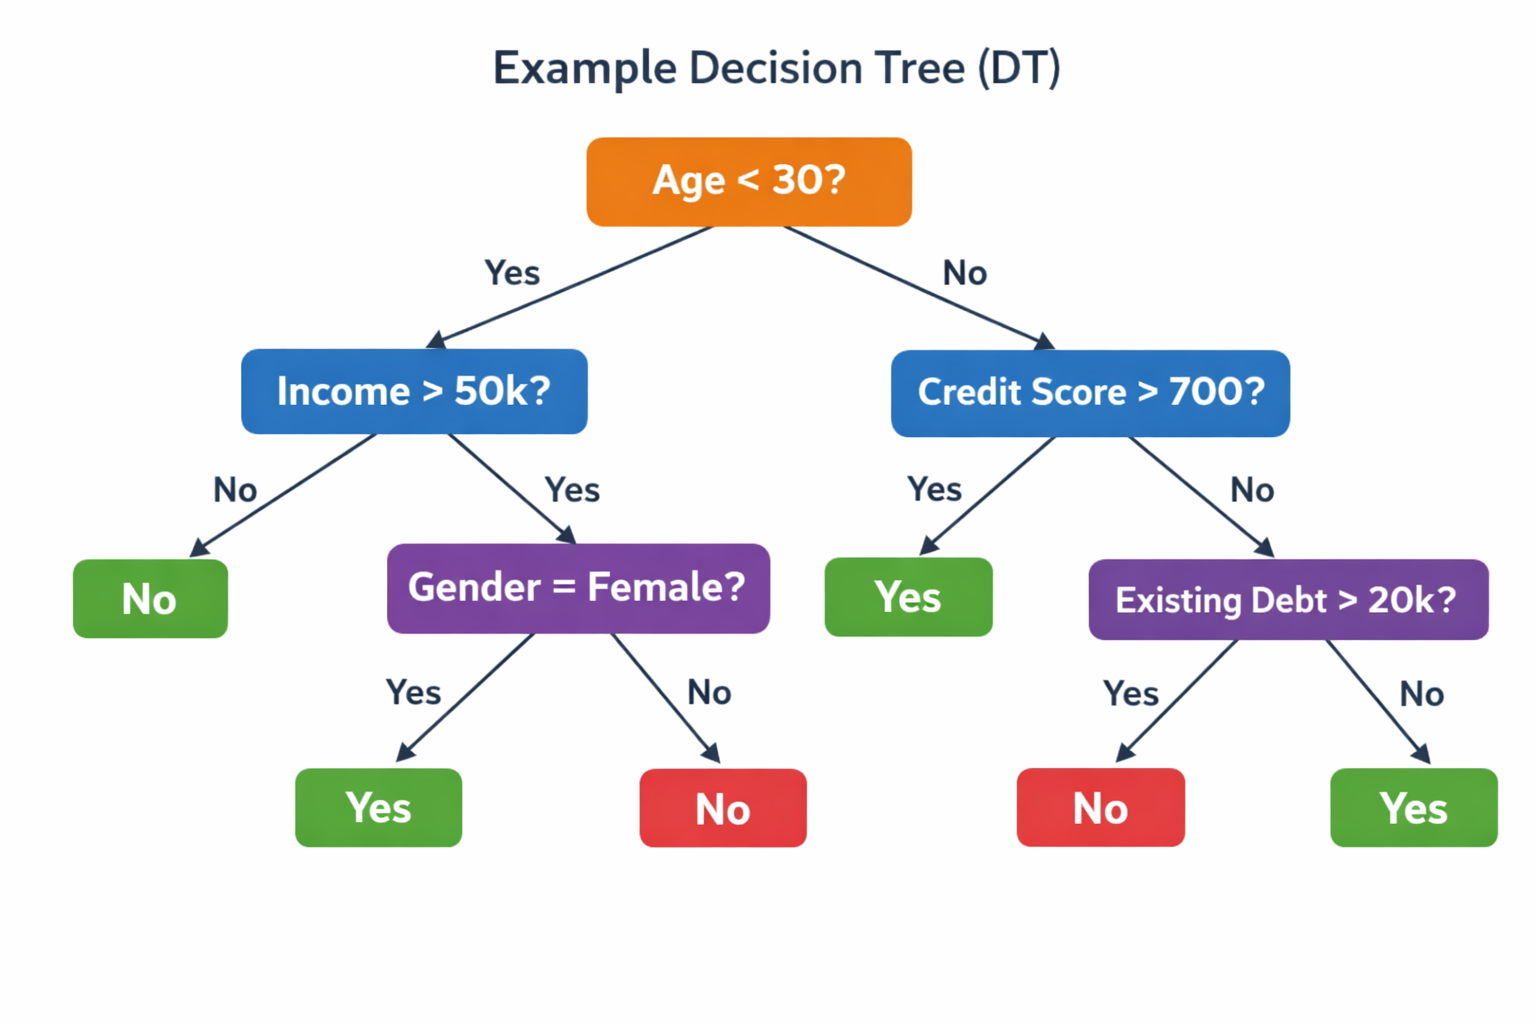

## **Purity of a Node**

A node is **pure** if all samples belong to the same class.

Example:

Node A:
[Yes, Yes, Yes] → perfectly pure

Node B:
[Yes, No, Yes] → impure

Decision trees use a mathematical metric to measure impurity.
The most common one is **Entropy**.

## **Entropy**


Entropy measures the **uncertainty or disorder** in a dataset.

In the context of decision trees, entropy tells us **how mixed the classes are in a node**.

- If all samples belong to the same class → **low entropy**
- If samples are evenly mixed between classes → **high entropy**

A decision tree tries to **reduce entropy when splitting the data**.

---

## **Mathematical Definition**

Entropy is defined as:

$$
H(S) = - \sum_{i=1}^{C} p_i \log_2(p_i)
$$

Where:

- $H(S)$ = entropy of dataset $S$
- $C$ = number of classes
- $p_i$ = probability of class $i$

The probability of a class is:

$$
p_i = \frac{\text{number of samples in class } i}{\text{total number of samples}}
$$

---

## **Example 1 — Perfectly Pure Node**

Dataset:[Yes, Yes, Yes, Yes]


Probabilities:

$$
p(Yes) = 1
$$

Entropy:

$$
H(S) = - (1 \cdot \log_2(1))
$$

Since:

$$
\log_2(1) = 0
$$

We get:

$$
H(S) = 0
$$

This means **no uncertainty** — the node is perfectly pure.

---

## **Example 2 — Mixed Node**

Dataset:[Yes, No, Yes, No]


Probabilities:

$$
p(Yes) = \frac{2}{4} = 0.5
$$

$$
p(No) = \frac{2}{4} = 0.5
$$

Entropy:

$$
H(S) = - (0.5\log_2(0.5) + 0.5\log_2(0.5))
$$

Since:

$$
\log_2(0.5) = -1
$$

We get:

$$
H(S) = - (0.5(-1) + 0.5(-1))
$$

$$
H(S) = 1
$$

This represents **maximum uncertainty**.

---

## **Range of Entropy**

For a **binary classification problem**:

$$
0 \leq H(S) \leq 1
$$

- **0** → perfectly pure node  
- **1** → completely mixed classes (50/50)

For **multiple classes**, the maximum entropy becomes:

$$
H_{max} = \log_2(C)
$$

where $C$ is the number of classes.

Example:

| Number of Classes | Maximum Entropy |
|-------------------|----------------|
| 2 | 1 |
| 3 | 1.58 |
| 4 | 2 |

---

## **Intuition**

Entropy can be understood as **how difficult it is to guess the class label**.

| Node | Entropy | Interpretation |
|-----|-----|-----|
| [Yes, Yes, Yes] | 0 | Completely certain |
| [Yes, Yes, No] | Low | Mostly certain |
| [Yes, No, Yes, No] | High | Very uncertain |

Decision trees choose splits that **reduce entropy as much as possible**, creating nodes that are **more pure**.